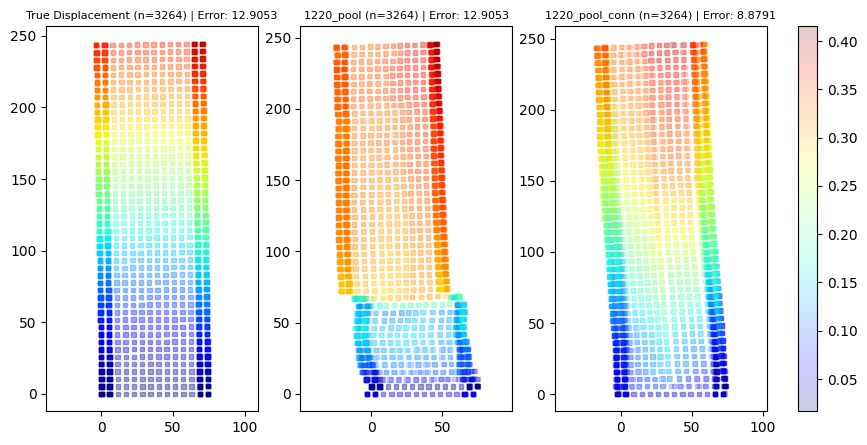

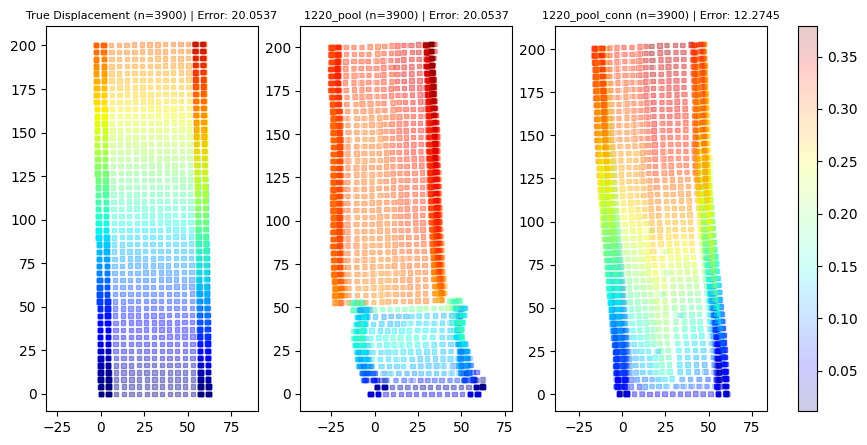

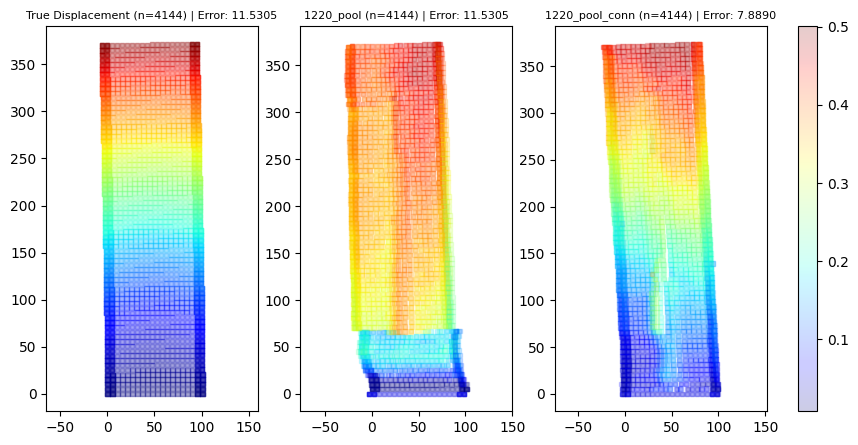

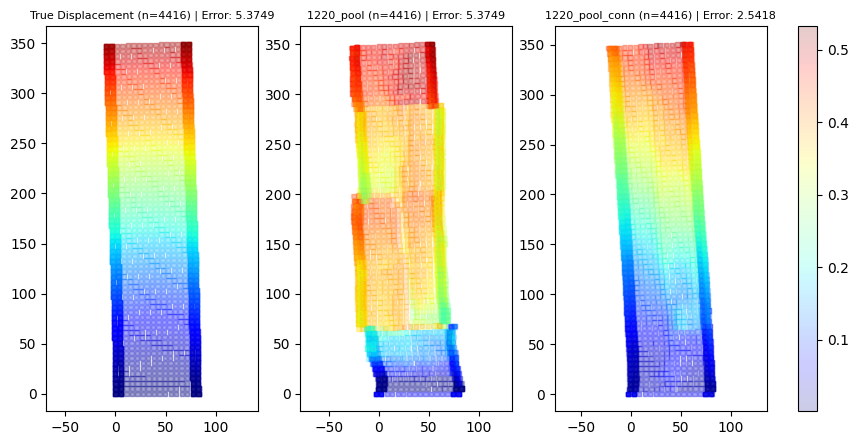

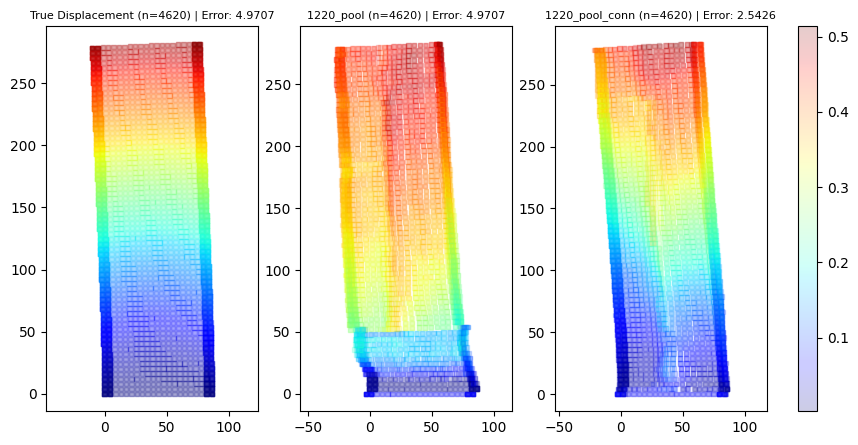

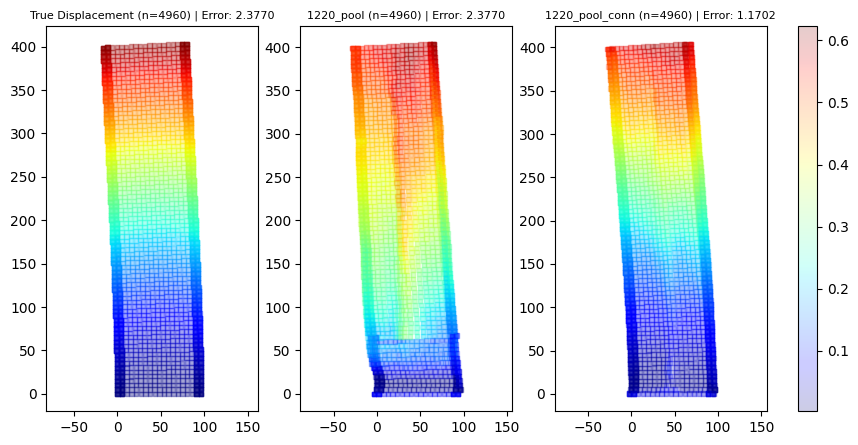

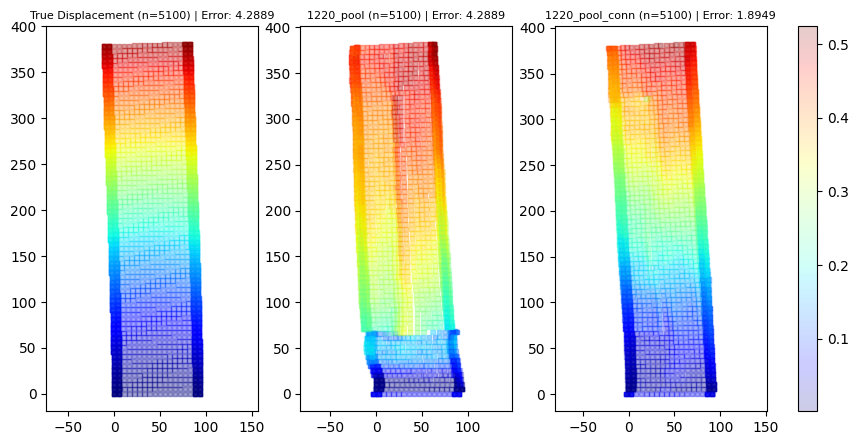

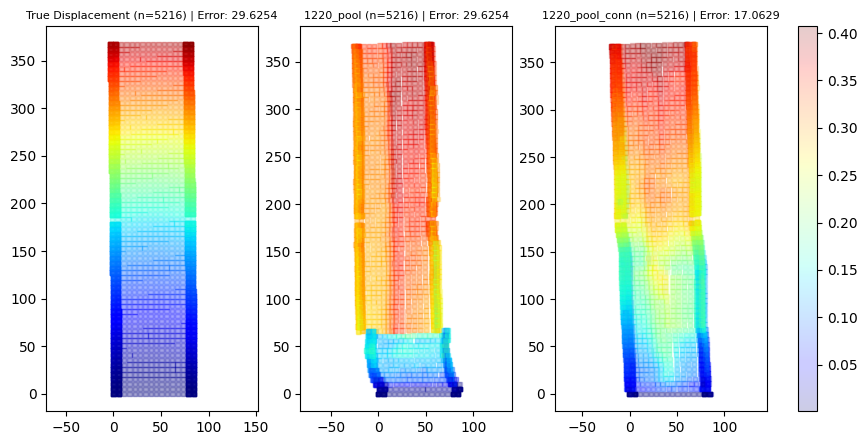

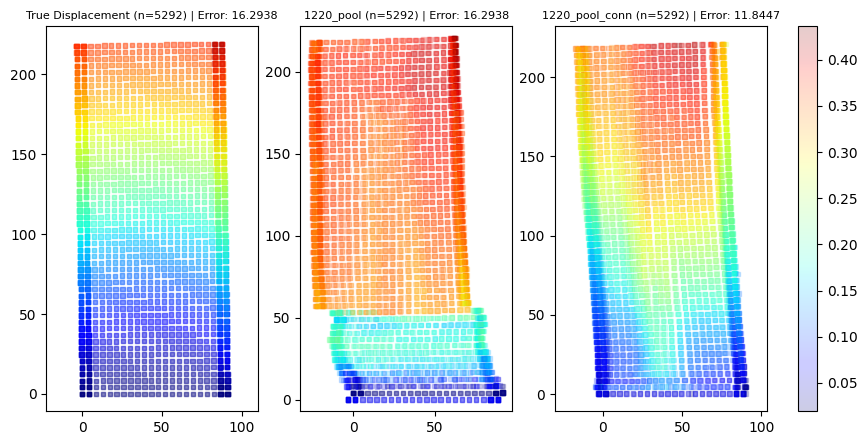

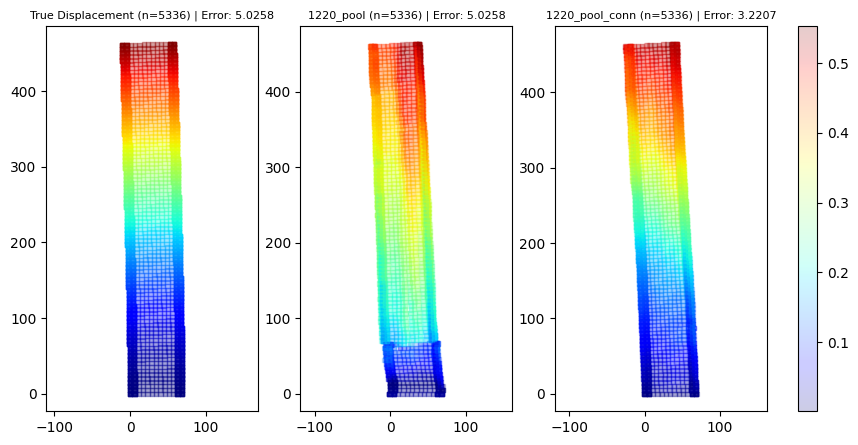

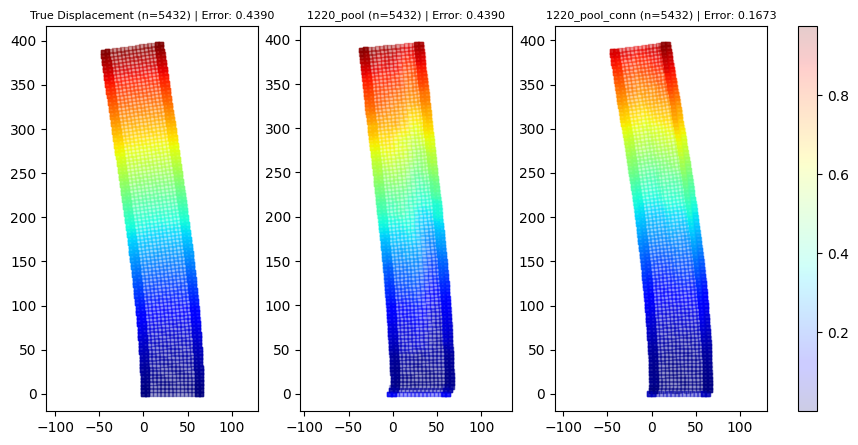

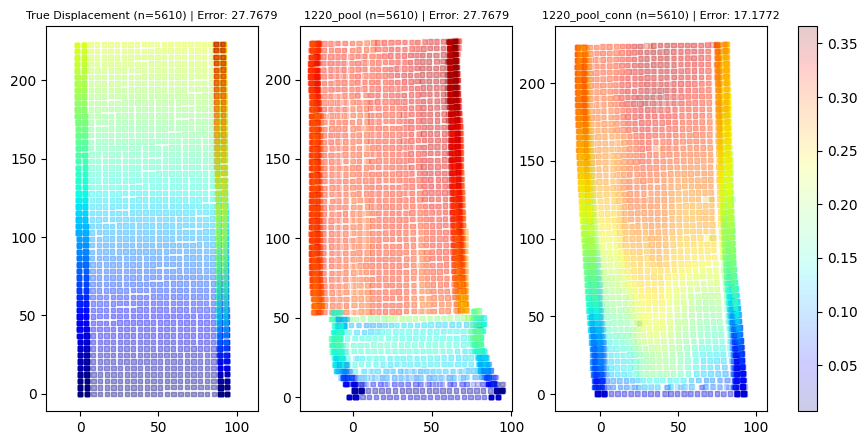

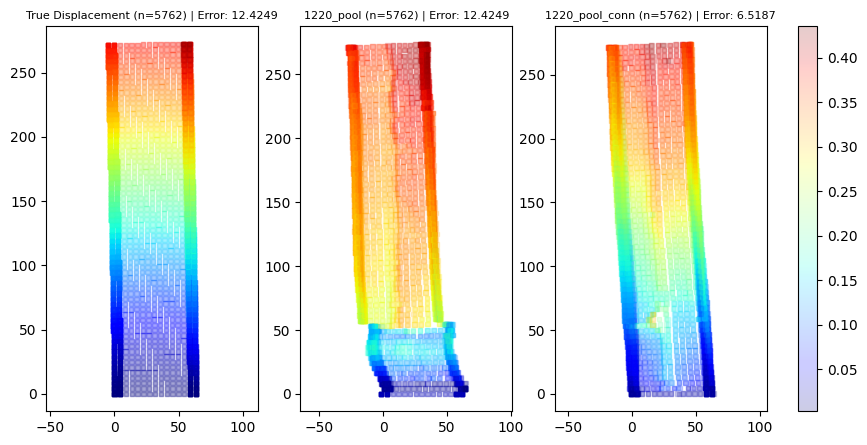

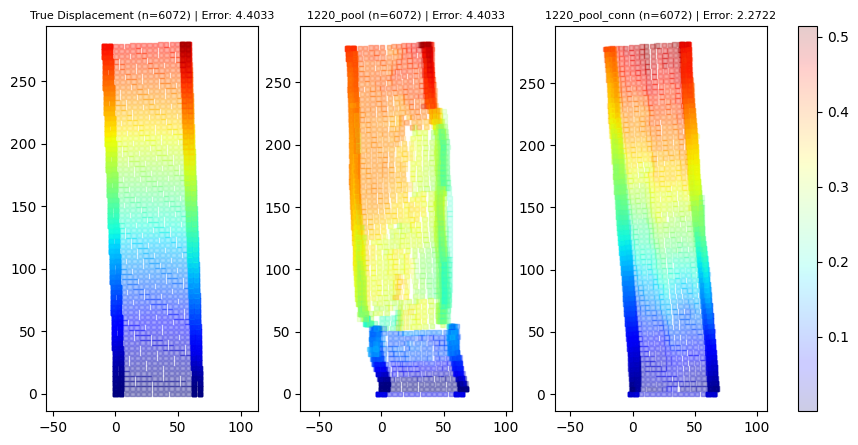

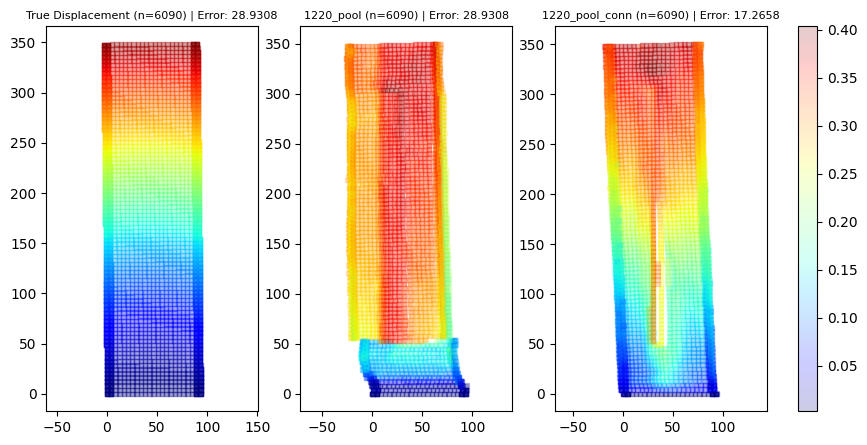

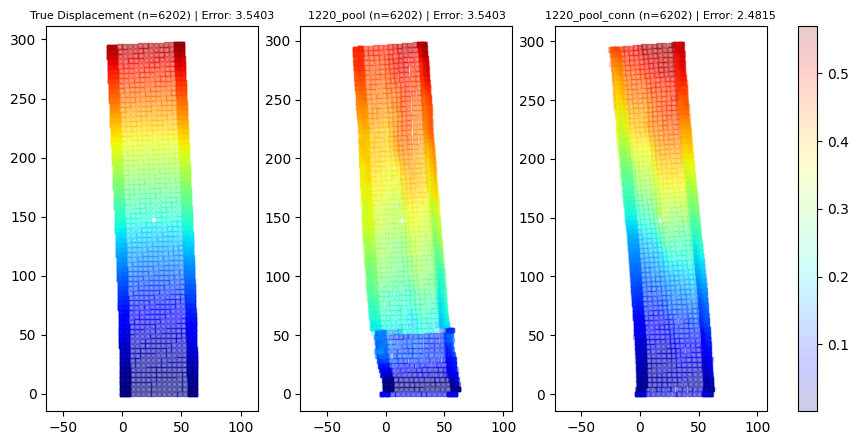

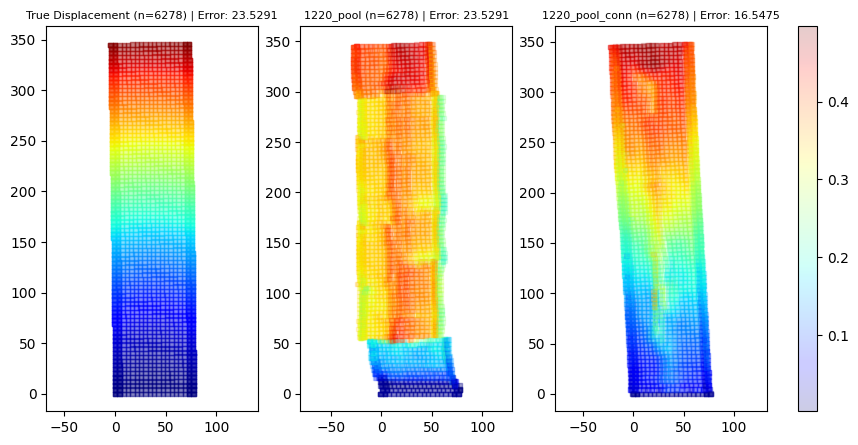

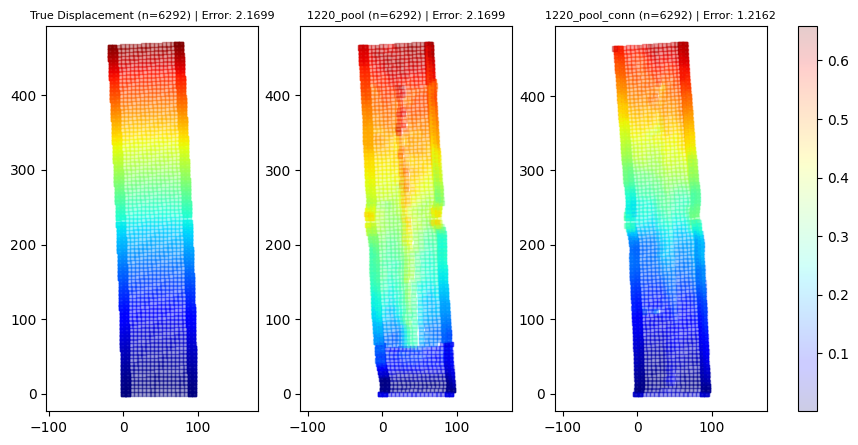

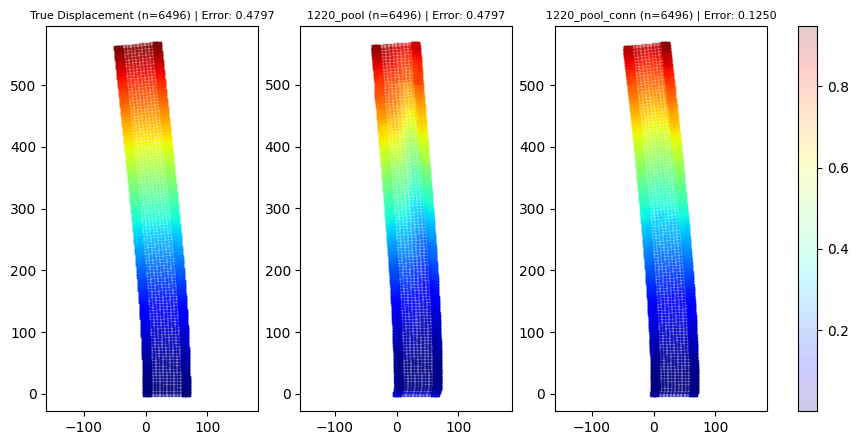

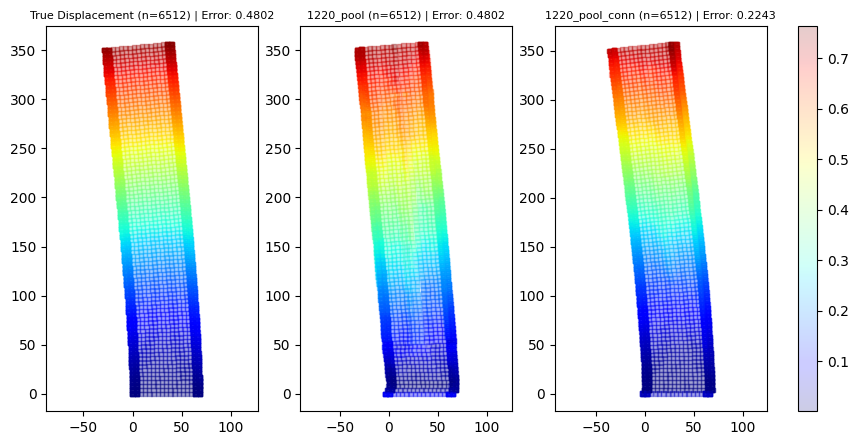

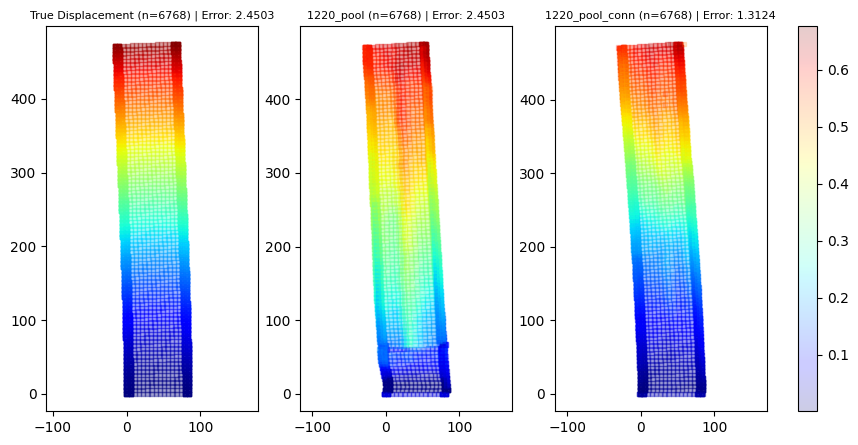

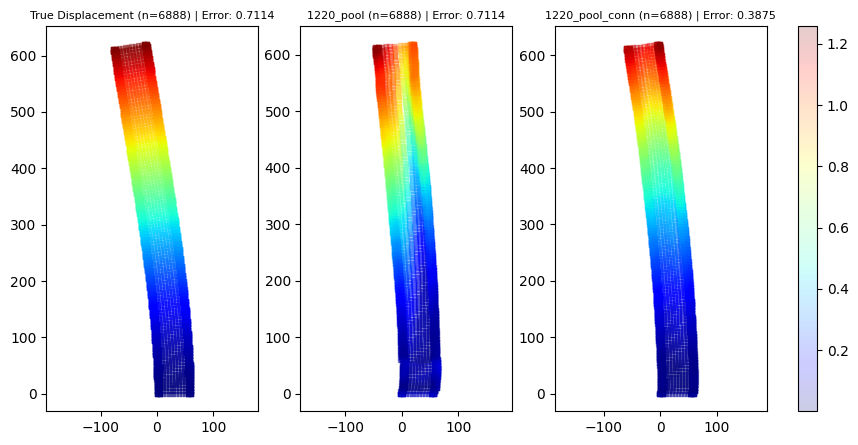

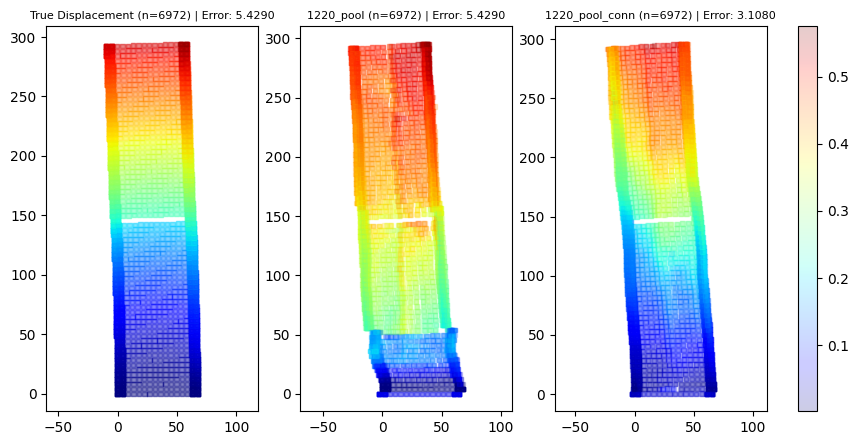

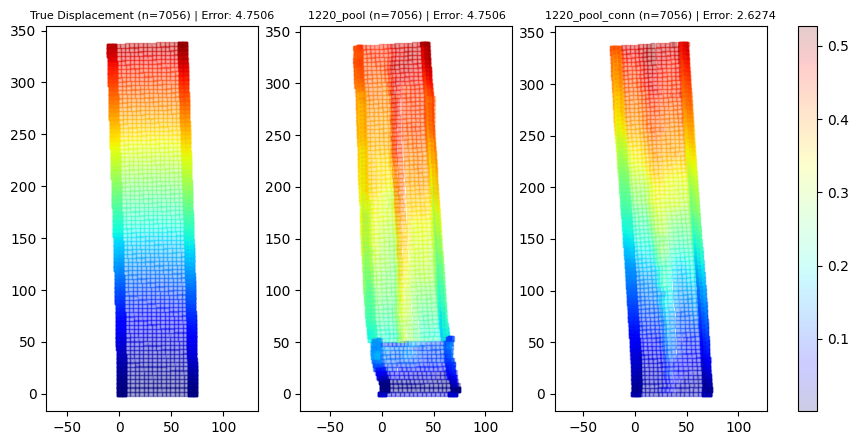

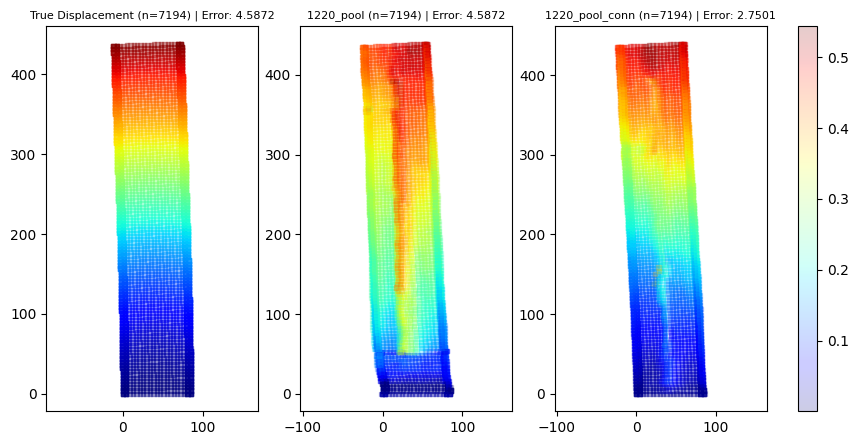

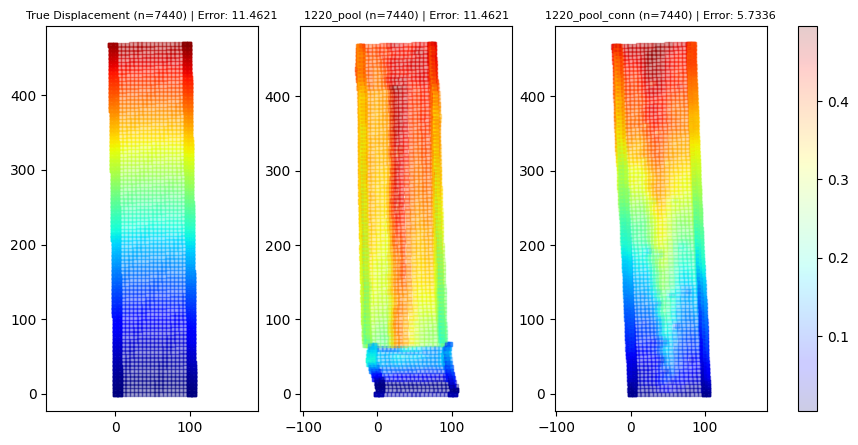

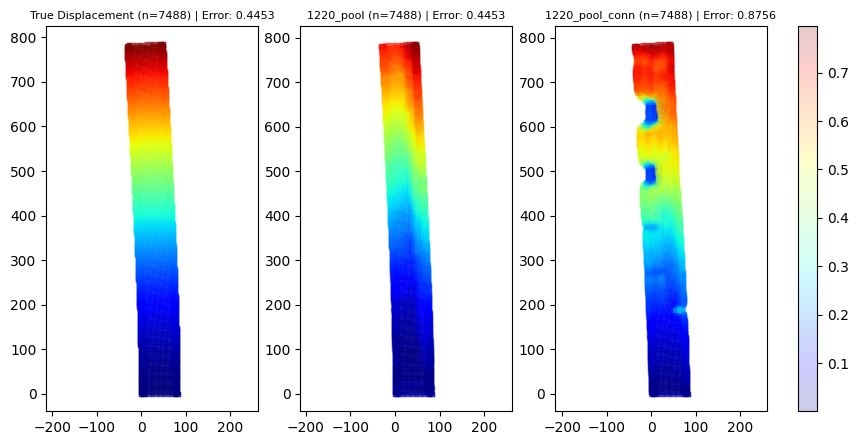

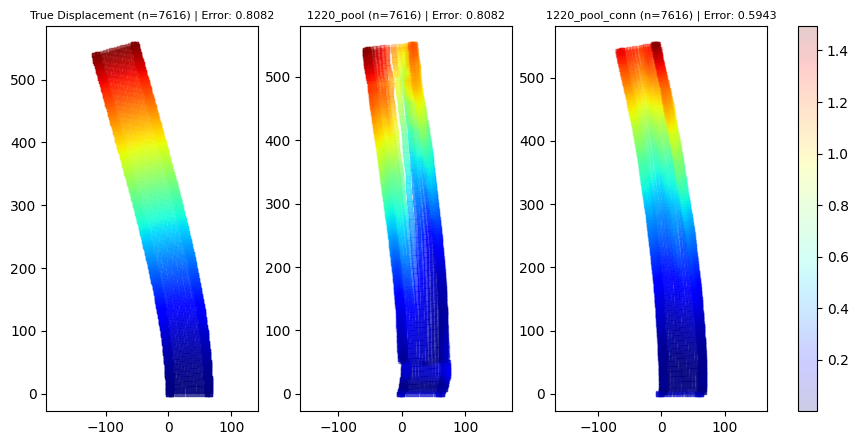

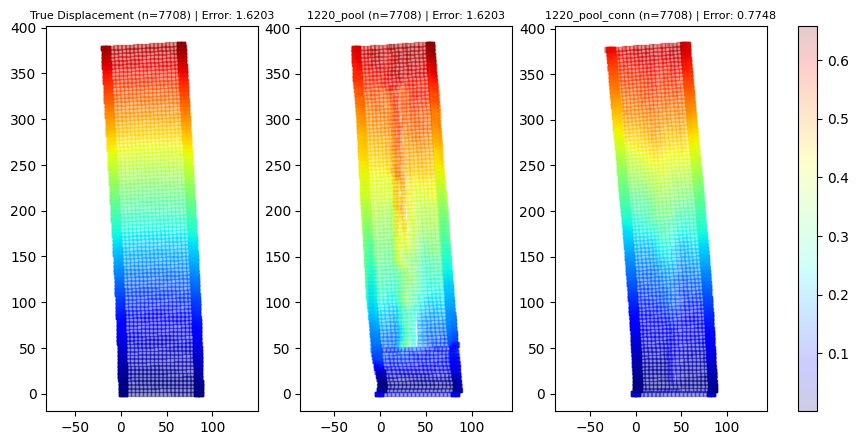

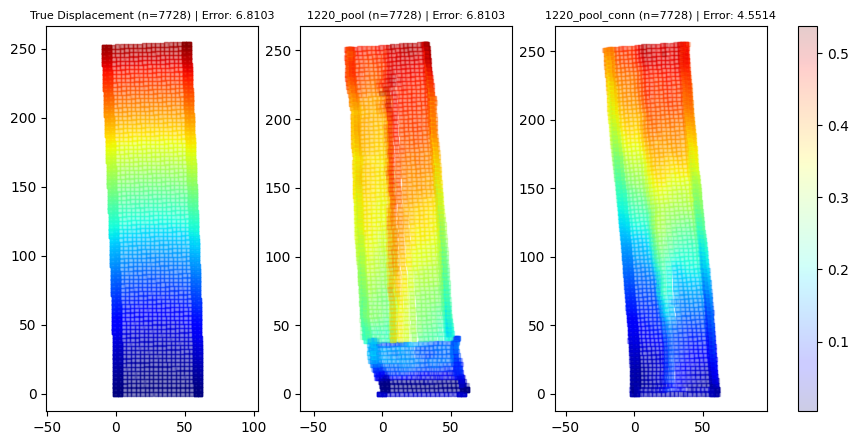

In [ ]:
## Visualization - Matplotlib 3D Scatter Plot of all samples: compare methods
import matplotlib.pyplot as plt
import numpy as np
import torch
alias1 = '1220_pool'
alias2 = '1220_pool_conn'
#out_samples = torch.load("../base/test_dataset/preds_1208_conn.pt",weights_only=False)
out_samples1 = torch.load(f"../genconv/{alias1}/preds_{alias1}.pt",weights_only=False)
out_samples2 = torch.load(f"../genconv/{alias2}/preds_{alias2}.pt",weights_only=False)
sample = 4

#sc = ax.scatter(out_samples[sample]['nodes']['pos'],'k',alpha=0.3,label='initial position')
#ax[i,1].plot(out_samples[sample]['nodes']['pred_u'][:],alpha=0.3,label='predicted')

#ax.plot_trisurf(V[:,0],V[:,1],V[:,2],triangles=F,edgecolor='#888888',linewidth=lw,antialiased=True,color='#dddddd',alpha=0.1)

def n_nodes(sample):
    return sample['nodes']['pos'].shape[0]
map1 = {n_nodes(s): s for s in out_samples1}
map2 = {n_nodes(s): s for s in out_samples2}
keys = sorted(set(map1) & set(map2))

def process(s):
    pos_init = s['nodes']['pos']
    pos_true = pos_init + s['nodes']['y_u'] * vis_scale
    pos_pred = pos_init + s['nodes']['pred_u'] * vis_scale
    pos_diff = np.linalg.norm(s['nodes']['y_u'], axis=-1)
    pos_diff_pred = np.linalg.norm(s['nodes']['pred_u'], axis=-1)
    mask = pos_diff > 1e-6
    pos_delta = np.mean(np.abs(pos_diff_pred[mask] - pos_diff[mask]) / pos_diff[mask]) if mask.any() else 0.0
    return pos_true, pos_pred, pos_diff, pos_diff_pred, pos_delta

for sample in range(0,30):
    k = keys[sample]  # or pick any key you want
    s1 = map1[k]
    s2 = map2[k]

    vis_scale = 50


    pos_true1, pos_pred1, pos_diff1, pos_diff_pred1, pos_delta1 = process(s1)
    pos_true2, pos_pred2, pos_diff2, pos_diff_pred2, pos_delta2 = process(s2)

    fig, axes = plt.subplots(1, 3, figsize=(10, 5))

    panels = [
        (axes[0], pos_true1, pos_diff1, pos_diff1, f'True Displacement (n={k})', pos_delta1),
        (axes[1], pos_pred1, pos_diff1, pos_diff_pred1, f'{alias1} (n={k})', pos_delta1),
        (axes[2], pos_pred2, pos_diff2, pos_diff_pred2, f'{alias2} (n={k})', pos_delta2),
    ]

    for ax, pos_pred, pos_diff, pos_diff_pred, title, pos_delta in panels:
        sc = ax.scatter(pos_pred[:,1], pos_pred[:,2], s=10, marker='s', c=pos_diff_pred, cmap='jet', alpha=0.2)
        ax.set_title(f'{title} | Error: {pos_delta:.4f}',fontsize=8)
        ax.axis('equal')

    fig.colorbar(sc, ax=axes, fraction=0.03, pad=0.04)
    #plt.tight_layout()
    plt.show()

In [1]:
## PyG Graph with Mesh Nodes
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import glob
import numpy as np
from scipy.spatial import KDTree
from scipy.stats import norm
import torch
from torch_geometric.data import Data
import pandas as pd

torch.set_default_dtype(torch.float64)

# Material encoding (1-h)
def load_material_vocab() -> Tuple[Dict[str, int], Dict[int, str]]:
    labels = ['steel'] #fixed
    vocab = {lbl: i for i, lbl in enumerate(labels)}
    return vocab

def one_hot(vocab: Dict[str, int], device=None, dtype=torch.float) -> torch.Tensor:
    vec = torch.ones(len(vocab), dtype=dtype, device=device) #elements only placeholder
    return vec

def stiffness_to_node_adj_edge_index(K: torch.Tensor, num_nodes: int, dof_per_node: int = 3) -> torch.Tensor: #mesh-mesh nodes
    K = K.coalesce()
    dof_rows, dof_cols = K.indices()
    node_rows = torch.div(dof_rows, dof_per_node, rounding_mode="floor")
    node_cols = torch.div(dof_cols, dof_per_node, rounding_mode="floor")
    ei = torch.stack([node_rows.long(), node_cols.long()], dim=0)
    mask = ei[0] != ei[1]
    ei = ei[:, mask]
    ei = torch.unique(ei, dim=1)
    return ei

def incidence_edges_from_conn(conn: np.ndarray, nodes: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    Nc, Nv = conn.shape
    c_idx = np.repeat(np.arange(Nc, dtype=np.int64), Nv)
    n_idx = conn.reshape(-1)
    edge_index = torch.from_numpy(np.vstack([c_idx, n_idx])).long()
    node_tensor = nodes.to(edge_index.device)
    conn_tensor = torch.from_numpy(conn).long().to(edge_index.device)
    #edge attribute -> mesh to element centroid in xyz
    elem_nodes = node_tensor[conn_tensor]
    centroids = elem_nodes.mean(dim=1, keepdim=True)
    rel_disp = (elem_nodes - centroids).reshape(-1, elem_nodes.size(-1))

    return edge_index, rel_disp

def mesh_edges_from_conn(conn: torch.Tensor) -> torch.Tensor:
    conn = conn.long()                             # [E, nverts]
    hex_edges = torch.tensor([
        [0,1], [1,2], [2,3], [3,0],     # bottom face
        [4,5], [5,6], [6,7], [7,4],     # top face
        [0,4], [1,5], [2,6], [3,7],     # vertical edges
    ])
    pairs = conn[:,hex_edges]          # [E, 12, 2]
    pairs = pairs.reshape(-1, 2)
    pairs = torch.unique(torch.sort(pairs, dim=1).values, dim=0).T
    edge_index = pairs
    return edge_index

def mesh_edges_nearest(nodes: torch.Tensor) -> torch.Tensor:
    # build mesh connections from nearest neighbors
    num_nodes = int(nodes.size(0))
    if num_nodes < 2:
        return torch.empty((2, 0), dtype=torch.long, device=nodes.device)

    coords = nodes.detach().cpu().numpy()
    k = min(8, num_nodes - 1)
    _, nn_idx = KDTree(coords).query(coords, k=k + 1, workers=-1)
    neighbors = nn_idx[:, 1:].reshape(-1)  # drop self
    src = np.repeat(np.arange(num_nodes, dtype=np.int64), k)

    pairs = torch.from_numpy(np.stack([src, neighbors], axis=1))
    pairs = torch.sort(pairs, dim=1).values
    pairs = torch.unique(pairs, dim=0)
    return pairs.t().to(nodes.device)

def nodes_topology_info(nodes: torch.Tensor) -> torch.Tensor:
    # build 3D descriptors of nearest neighbors, fitting into a distribution
    coords = nodes.detach().cpu().numpy()  # [N, 3]
    num_nodes = coords.shape[0]

    k = min(125, num_nodes - 1)  # cap k to available neighbors
    _, nn_idx = KDTree(coords).query(coords, k=k + 1, workers=-1)  # include self
    neighbor_idx = nn_idx[:, 1:]  # drop self index, shape (N, k)

    neighbor_coords = coords[neighbor_idx]             # (N, k, 3)
    rel = neighbor_coords - coords[:, None, :]         # relative vectors
    mu = torch.from_numpy(rel.mean(axis=1))                              # (N, 3)
    sigma = torch.from_numpy(rel.std(axis=1, ddof=0))                    # (N, 3)
    return torch.cat([mu, sigma], dim=1)


# Connectivity
# mesh nodes <-> mesh nodes
# mesh nodes <-> element nodes

def data_to_graph(path:str,device):
    data = Data()
    simdata = torch.load(path,weights_only=False)
    conn = simdata["elements"]
    conn = conn.cpu().numpy() if isinstance(conn, torch.Tensor) else np.asarray(conn)
    nodes = simdata['nodes']
    top_desc = nodes_topology_info(nodes)
    #c2n_ei, c2n_w = incidence_edges_from_conn(conn,nodes)  # [2, E_cn], [E_cn, 1]
    
    # mesh node properties: positions, forces, BC, dirichlet displacement
    data.pos = nodes #                                             [N,3]
    data.bc = simdata['boundary']
    data.f_ext = simdata['ext_forces'] #forces in timeseries format     [T,N,3]
    data.tpl = top_desc #nearest-neighbor topology descriptors    [N,6]

    # element node properties: material, stiffness matrix
    #data['elements'].stiffness = #stiffness is a learned feature

    # target properties
    # mesh: displacement over time
    data.f_ts = simdata['forces'] #forces in timeseries format     [T,N,3]
    data.u_ts = simdata['u_history']

    # mesh-mesh: distance
    #ei = stiffness_to_node_adj_edge_index(simdata["stiffness"], num_nodes=nodes.size(0), dof_per_node=nodes.size(1))
    ei = mesh_edges_from_conn(simdata["elements"]) # [2,N]
    #ei = mesh_edges_nearest(nodes)
    src, dst = ei
    #edge_mat = one_hot(vocab, device=device).unsqueeze(0).repeat(int(ei.shape[1]), 1)
    disp = (nodes[dst] - nodes[src]).float()
    data.edge_index = ei
    #data.edge_index = ei.flip(0)
    data.edge_attr = disp
    #data.edge_attr = -disp
    
    #data['nodes'].edge_index = stiffness_to_node_adj_edge_index(simdata["stiffness"], num_nodes=nodes.size(0), dof_per_node=nodes.size(1)) #from stiffness matrix, only connectivity

    #print(data['nodes'].num_nodes)                              # N
    #print(data['elements'].num_nodes)                           # E
    #print(data.num_edges)                                       # 2*((E*num_vertices)+())
    #print(data['nodes','adjacent','nodes'].num_edges)           # 
    #print(data['nodes','adjacent_rev','nodes'].num_edges)       #
    #print(data['elements','contributes','nodes'].num_edges)     # E*num_vertices
    #print(data['nodes','belongs_to','elements'].num_edges)      # E*num_vertices

    #data = data.pin_memory()
    data = data.to(device)
    return data

#data_to_graph('../base/torchfem_dataset/processed/simulation_dump_3.pt','../base/torchfem_dataset/processed/mat.csv',device)

def generate_dataset(data_dir:str):
    device = torch.device('cpu')
    file = data_dir
    samples = []
    #for file in files:
        #if filename > 50:
        #    continue
    data = data_to_graph(file,device)
    samples.append(data)
    print(file)

    print(len(samples))
    return samples

dataset = generate_dataset('../datasets/simple_beam/sim_2.pt')
torch.save(dataset, "../datasets/simple_beam/test_dataset.pt")

../datasets/simple_beam/sim_2.pt
1


In [3]:
from torch_geometric.utils import is_undirected, to_undirected

#ei = dataset['edge_index'].T
ea = dataset[0].edge_attr
edge_index = dataset[0].edge_index
#edge_index,ea = to_undirected(edge_index,edge_attr=ea)
print('Undirected?' if is_undirected(edge_index) else 'Directed!')

Directed!


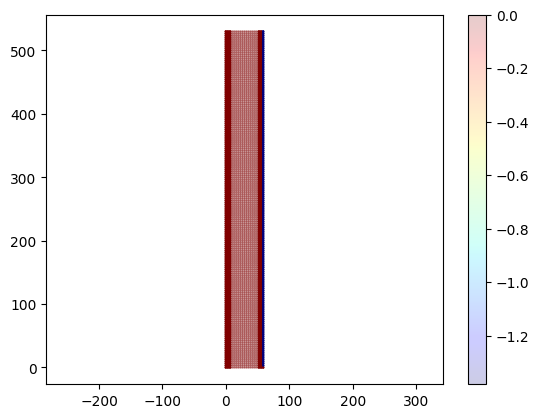

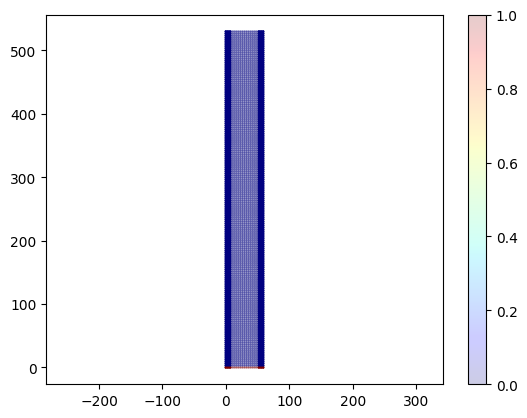

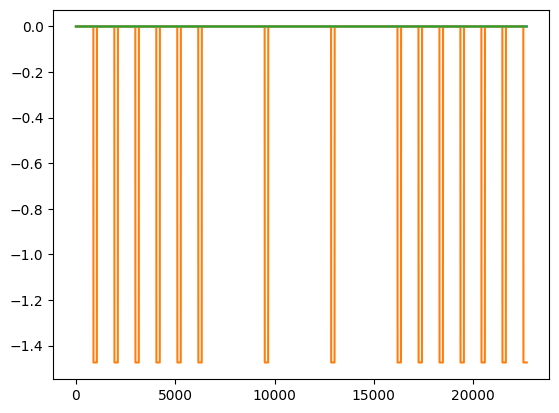

In [2]:
import matplotlib.pyplot as plt

nodes_pos = dataset[0].pos
attr = dataset[0].f_ext[-5,:,1]
attr2 = dataset[0].bc[:,1].float()
plt.scatter(nodes_pos[:,1],nodes_pos[:,2],alpha=0.2,s=0.5,c=attr, cmap='jet')
plt.colorbar()
plt.axis('equal')
plt.show()
plt.scatter(nodes_pos[:,1],nodes_pos[:,2],alpha=0.2,s=0.5,c=attr2, cmap='jet')
plt.colorbar()
plt.axis('equal')
plt.show()
plt.plot(dataset[0].f_ext[-2])

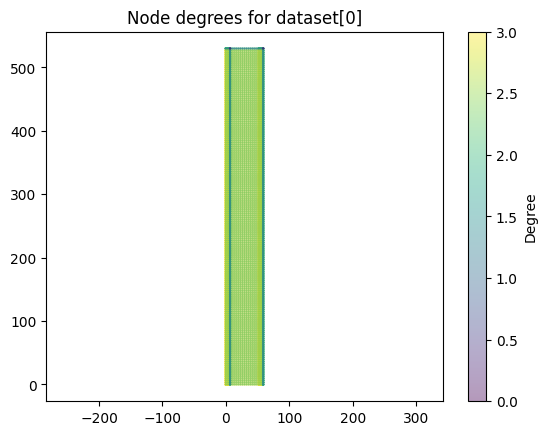

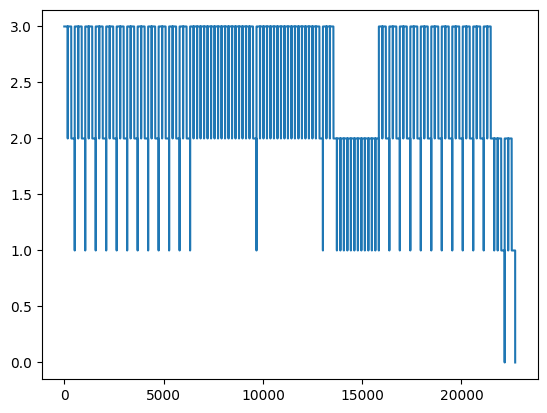

In [3]:
import matplotlib.pyplot as plt
from torch_geometric.utils import degree

# Plot node degree distribution for dataset[0]
edge_index = dataset[0].edge_index
ea = dataset[0].edge_attr
#edge_index,ea = to_undirected(edge_index,edge_attr=ea)
node_degrees = degree(edge_index[0], dataset[0].num_nodes).cpu().numpy()
plt.scatter(nodes_pos[:,1], nodes_pos[:,2], alpha=0.4, s=.5, c=node_degrees, cmap='viridis')
plt.colorbar(label='Degree')
plt.axis('equal')
plt.title('Node degrees for dataset[0]')
plt.show()
plt.plot(node_degrees)

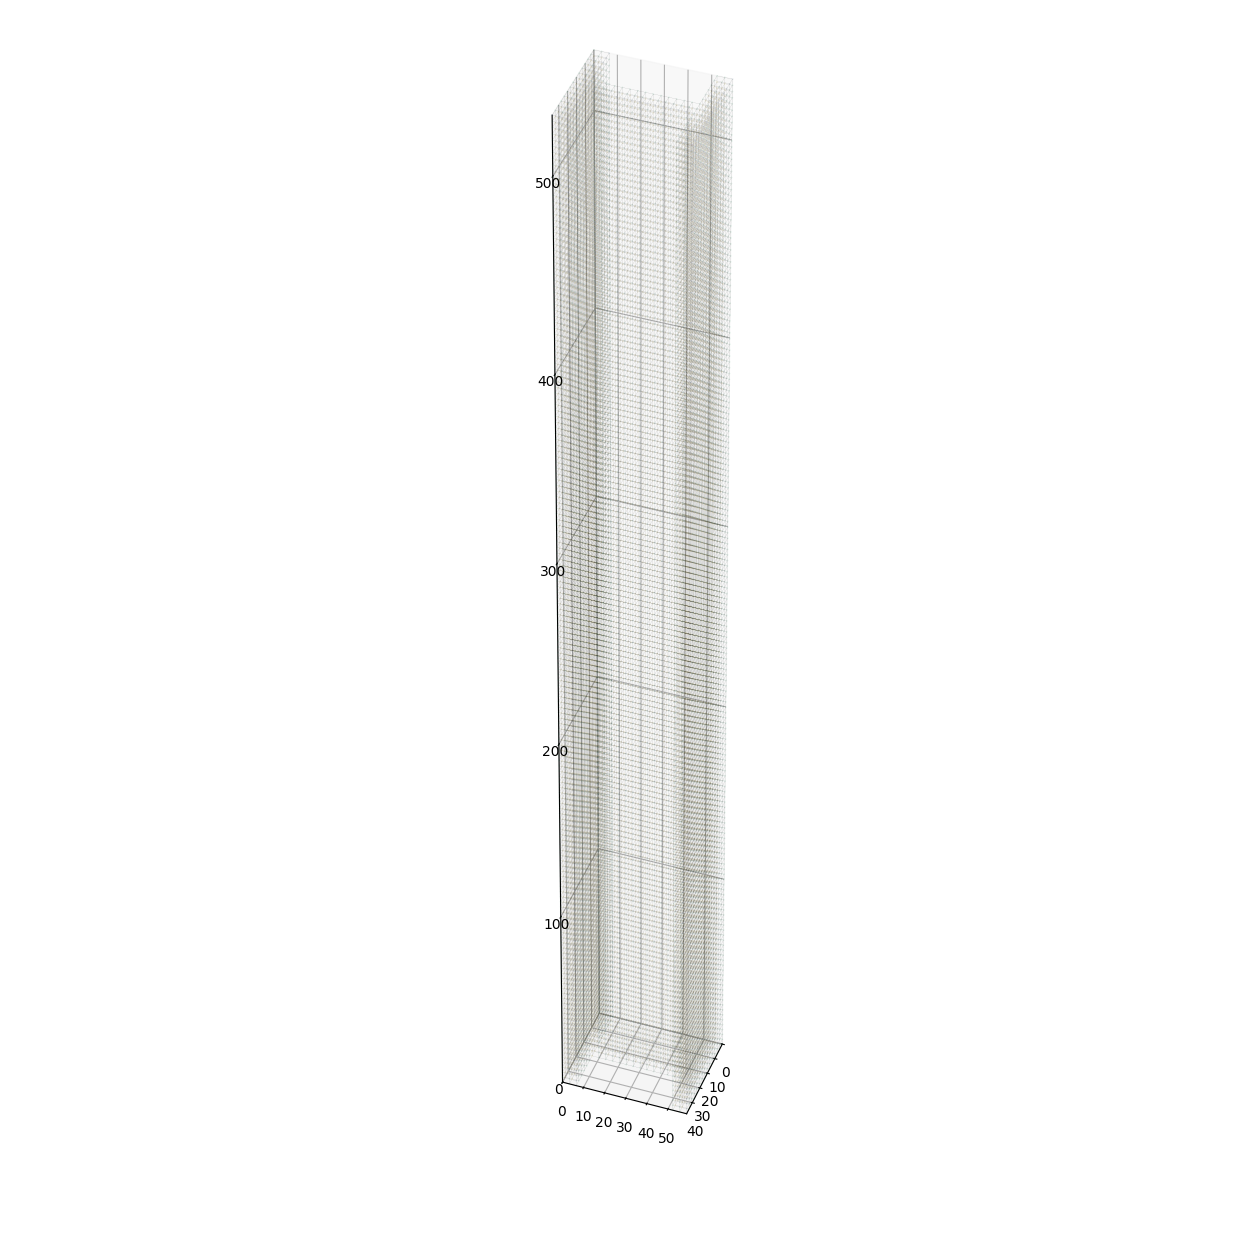

In [12]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16,16))
ax = fig.add_subplot(111,projection='3d')
ax.view_init(elev=40,azim=20)
sc = ax.scatter(nodes_pos[:,0],nodes_pos[:,1], nodes_pos[:,2], alpha=0.4, s=.01, c=node_degrees, cmap='viridis')
lines = nodes_pos[edge_index.T]
#sc2 = ax.plot(lines[:,:,0],lines[:,:,1],lines[:,:,2],linewidth=0.1)

from mpl_toolkits.mplot3d.art3d import Line3DCollection
lc = Line3DCollection(lines, linewidths=0.1, colors="k", alpha=0.4)
ax.add_collection3d(lc)

#xs = np.column_stack([lines[:, 0, 0], lines[:, 1, 0], np.full(len(lines), np.nan)]).ravel()
#ys = np.column_stack([lines[:, 0, 1], lines[:, 1, 1], np.full(len(lines), np.nan)]).ravel()
#zs = np.column_stack([lines[:, 0, 2], lines[:, 1, 2], np.full(len(lines), np.nan)]).ravel()
#ax.plot(xs, ys, zs, linewidth=0.1)

plt.axis('equal')

ranges = np.ptp(nodes_pos.T,axis=1)
ax.set_box_aspect(ranges)
# optionally tighten limits if you cropped anything
ax.set_xlim(nodes_pos[:, 0].min(), nodes_pos[:, 0].max())
ax.set_ylim(nodes_pos[:, 1].min(), nodes_pos[:, 1].max())
ax.set_zlim(nodes_pos[:, 2].min(), nodes_pos[:, 2].max())
plt.savefig('node_conn.png',dpi=600)